In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


DATA_FOLDER = '../data/'

In [ ]:


df = pd.read_csv(os.path.join(DATA_FOLDER, 'EWZ.csv'), sep=";")


# First row: AKS, I don't know what it is
# Second row: Unit: MWh, constant value
df.drop(index=[0, 1], inplace=True)

# delta time: 15 minutes

print(df.shape)
df.head()

C:\Users\matya\AppData\Local\Temp\ipykernel_12512\4192637435.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(DATA_FOLDER, 'EWZ.csv'), sep=";")


(340462, 102)


,Name,Wärmezähler UST 10 Spitalstrasse 6 Regionalspital Surselva WZ11,Wärmezähler Ölkessel Spital WZ10,Wärmezähler UST 62 Via Fontanivas Schwimmbad,Wärmezähler Holzkessel WT01 Direkt WZ1,Wärmezähler Holzkessel WT02 ORC WZ2,Wärmezähler Holzkessel WT03 AbWärmezähler WZ3,Wärmezähler Ölkessel Zentrale WZ5,Wärmezähler Ölkessel Zentrale REKU WZ8,Wärmezähler Fernleitung WZ6,...,Wärmezähler Spitalstrasse 7 UST 84,Wärmezähler Spitalstrasse 8 UST 85,Wärmezähler UST 86 Valserstrasse 7,Wärmezähler UST 87 Via Hans Erni 6,Wärmezähler UST 88 Glennerstrasse 10,Wärmezähler Via Schlifras 62/64 UST 89,Wärmezähler Via S. Clau Sura 25 UST 90,Wärmezähler Via Sogn Martin 1+3 UST 91,Wärmezähler Gassa Steffan Gabriel 1 UST 92,Wärmezähler Via Bual 30 UST 93
2,01.01.2016 00:15:00,0.0000,0.0000,0.0000,0.0000,0.2715,0.1000,0.0000,0.0000,0.3389,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,01.01.2016 00:30:00,0.0000,0.0000,0.0000,0.0000,0.2652,0.0276,0.0000,0.0000,0.3145,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,01.01.2016 00:45:00,0.0000,0.0000,0.0000,0.0000,0.2369,0.0724,0.0000,0.0000,0.3389,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,01.01.2016 01:00:00,0.0000,0.0000,0.0000,0.0000,0.2228,0.0946,0.0000,0.0000,0.2881,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,01.01.2016 01:15:00,0.0000,0.0000,0.0000,0.0000,0.2743,0.0324,0.0000,0.0000,0.3721,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [38]:
# Convert all values to float
sensor_columns = df.columns[1:]

df['Name'] = pd.to_datetime(df['Name'], dayfirst=True, errors='coerce')
print(type(df['Name'].values[0]))

for c in sensor_columns:
    df[c] = df[c].astype(np.float64)


<class 'numpy.datetime64'>


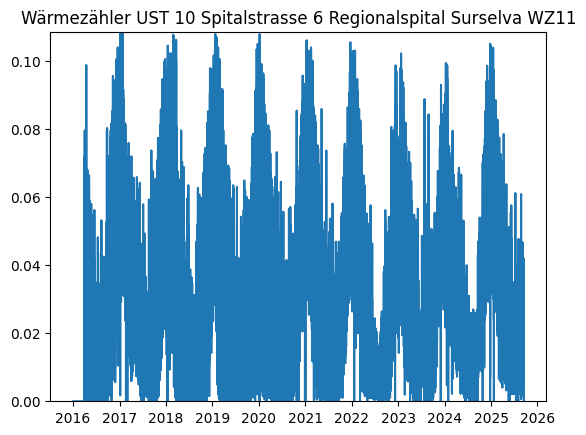

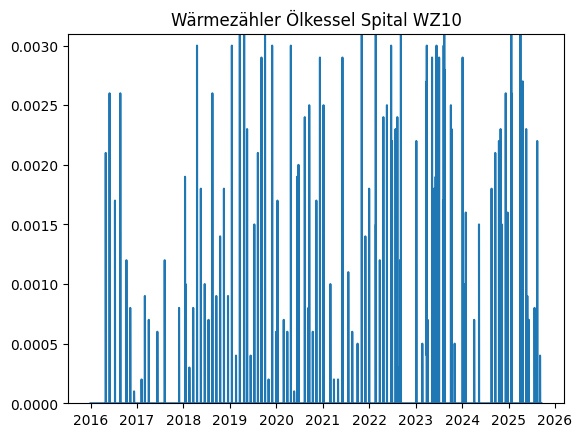

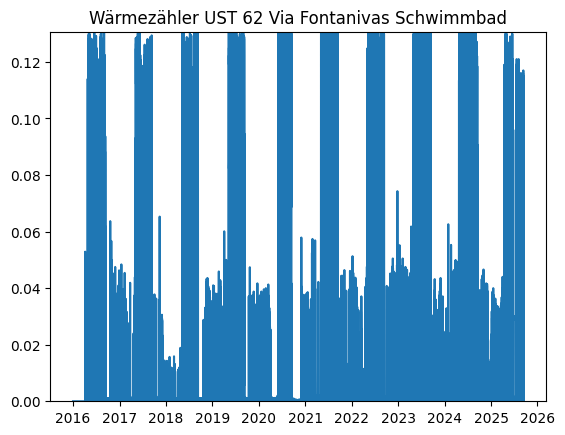

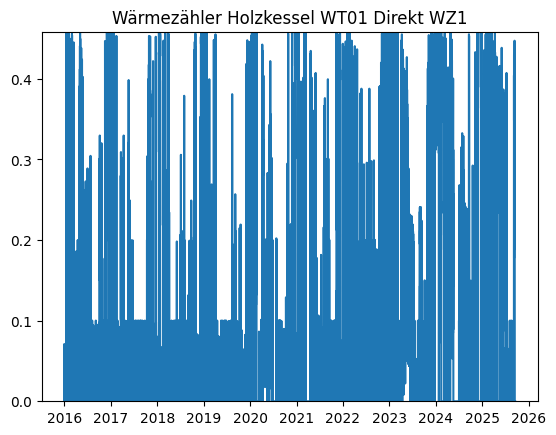

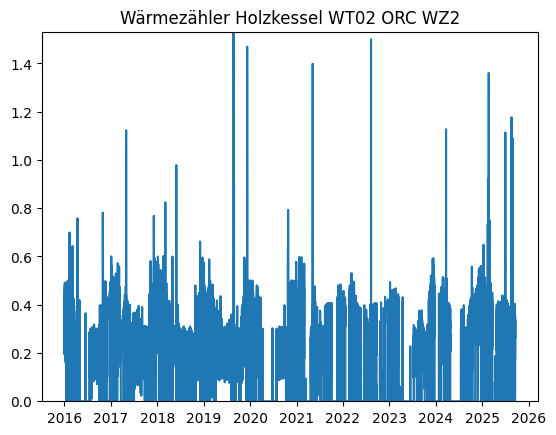

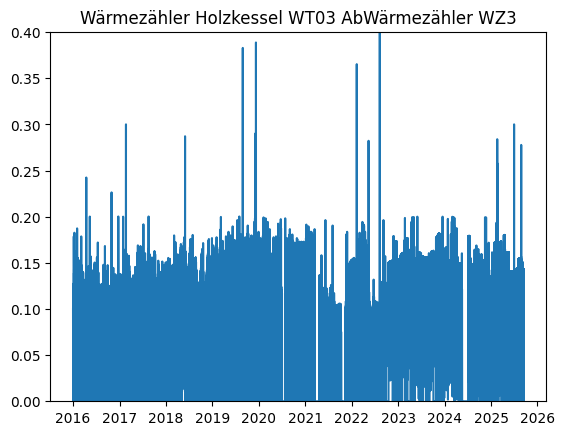

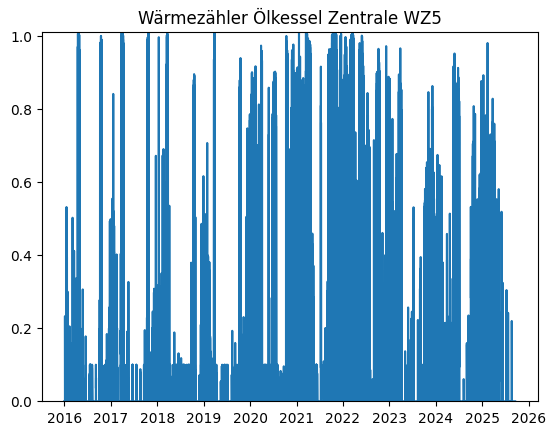

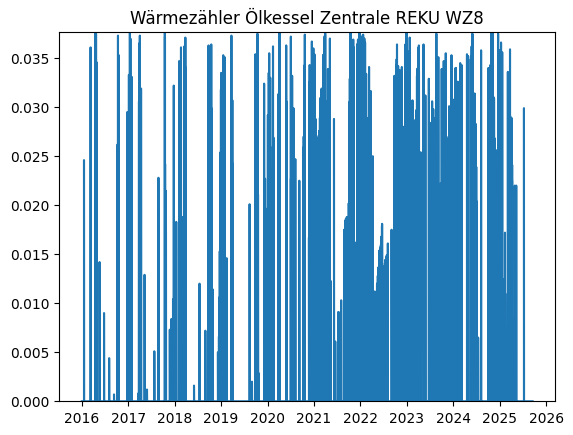

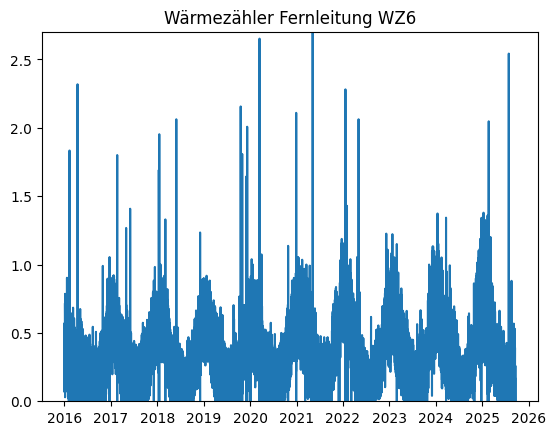

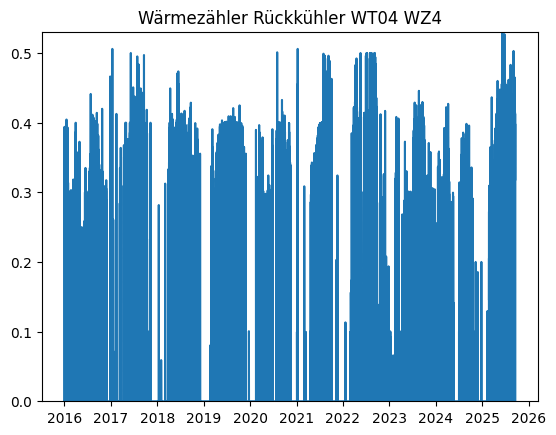

In [ ]:

for col in sensor_columns[:10]:
    values = df[col].values
    time = df['Name'].values
    mean = np.mean(values)
    std = np.std(values)

    # Clear out outliers
    mask = values <= mean + 3 * std

    values = values[mask]
    time = time[mask]



    plt.plot(time, values)
    plt.title(col)
    plt.ylim(0, 1.1 * np.max(values))
    plt.show()